# PlotStyle Quickstart

**PlotStyle** is a library that makes it easy to create figures that meet the formatting rules of scientific journals like Nature, Science, and IEEE.

Instead of manually adjusting font sizes, figure dimensions, and colors, you just tell PlotStyle which journal you're targeting and it handles everything.

**What you'll learn:**
- Apply a journal's style in one line with `plotstyle.use()`
- Create correctly sized figures with `plotstyle.figure()`
- Get colorblind-safe color palettes with `plotstyle.palette()`
- Check your figure against journal rules with `plotstyle.validate()`
- Save a submission-ready file with `plotstyle.savefig()`

> **Tip:** Run cells from top to bottom. The first code cell sets up everything needed for the examples below.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import plotstyle

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared x-axis data used in all plot examples below
x = np.linspace(0, 2 * np.pi, 200)

## 1. Discover Available Journals

PlotStyle includes built-in presets for many major scientific publishers.  Run the cell below to see the full list.

In [2]:
available = plotstyle.registry.list_available()
print(f"Available journals ({len(available)}): {', '.join(available)}")

Available journals (10): acs, cell, elsevier, ieee, nature, plos, prl, science, springer, wiley


## 2. Apply a Journal Style

`plotstyle.use("nature")` sets up Matplotlib to match Nature's figure guidelines — fonts, text sizes, line weights, and more.

Using it as a `with` block is recommended: the original settings are automatically restored when the block ends, so one example doesn't affect the next.

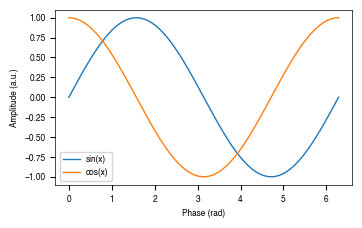

In [3]:
with plotstyle.use("nature"):
    # columns=1 → single-column width (89 mm for Nature)
    fig, ax = plotstyle.figure("nature", columns=1)
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)")
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.legend()
    plt.show()

## 3. Multi-Panel Figures

`plotstyle.subplots()` creates a figure with multiple panels, correctly sized for the journal.  It also automatically adds panel labels (a, b, c, …) in the right font and style.

Access each panel using `axes[row, column]` — for example, `axes[0, 0]` is the first panel and `axes[0, 1]` is the second.

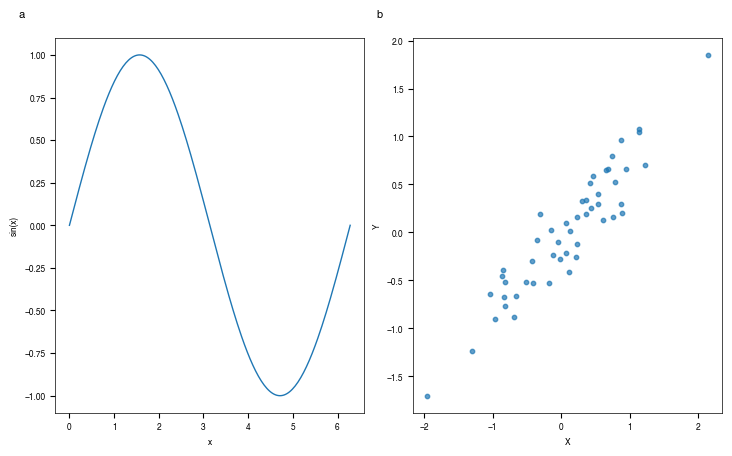

In [4]:
rng = np.random.default_rng(42)

with plotstyle.use("nature"):
    fig, axes = plotstyle.subplots("nature", nrows=1, ncols=2, columns=2)

    # Panel (a): line plot
    axes[0, 0].plot(x, np.sin(x))
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("sin(x)")

    # Panel (b): scatter plot
    xs = rng.normal(0, 1, 50)
    ys = 0.8 * xs + rng.normal(0, 0.3, 50)
    axes[0, 1].scatter(xs, ys, s=10, alpha=0.7)
    axes[0, 1].set_xlabel("X")
    axes[0, 1].set_ylabel("Y")

    plt.show()

## 4. Color Palettes

Each journal preset comes with a color palette designed to be readable by people with color vision deficiency.  Use `plotstyle.palette()` to get a list of colors you can pass directly to Matplotlib.

Colors: ['#E69F00', '#56B4E9', '#009E73', '#F0E442']


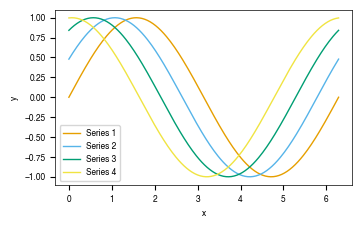

In [5]:
colors = plotstyle.palette("nature", n=4)
print("Colors:", colors)

with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature")
    for i, c in enumerate(colors):
        ax.plot(x, np.sin(x + i * 0.5), color=c, label=f"Series {i + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

## 5. Validate Before Submission

`plotstyle.validate()` checks your figure against the journal's rules — things like figure dimensions, font sizes, colors, and line weights.  It prints a report showing what passed, what failed, and how to fix any issues.

In [6]:
with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature")
    ax.plot(x, np.sin(x))
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    report = plotstyle.validate(fig, journal="nature")
    print(report)
    print(f"\nPassed: {report.passed}")
    plt.close(fig)

┌──────────────────────────────────────────────────────┐
│         PlotStyle Validation Report — Nature         │
├──────────┬───────────────────────────────────────────┤
│ ✓ PASS   │ No red-green colour pair detected.        │
│ ✓ PASS   │ Figure width 89.0mm matches single colu...│
│ ✓ PASS   │ Figure height 55.0mm is within the Natu...│
│ ✓ PASS   │ pdf.fonttype = 42 (TrueType fonts will ...│
│ ✓ PASS   │ ps.fonttype = 42 (TrueType fonts will b...│
│ ✓ PASS   │ savefig.dpi = 300.0 meets the Nature mi...│
│ ✓ PASS   │ All plotted lines and spines meet the N...│
│ ✓ PASS   │ All text elements are within the Nature...│
└──────────┴───────────────────────────────────────────┘
8/8 checks passed, 0 warning(s), 0 failure(s)

Passed: True


## 6. Export

`plotstyle.savefig()` saves your figure in a submission-ready format.  It automatically applies the journal's required resolution (DPI) and ensures fonts are embedded correctly — a common requirement of journal submission portals.

In [7]:
with plotstyle.use("nature"):
    fig, ax = plotstyle.figure("nature")
    ax.plot(x, np.sin(x))
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Amplitude")

    plotstyle.savefig(fig, OUTPUT_DIR / "quickstart_output.pdf", journal="nature")
    plt.close(fig)

print("Export complete.")

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Export complete.


✓ TrueType fonts embedded (pdf.fonttype=42)
✓ Resolution: 300.0 DPI
✓ Dimensions: 3.50in x 2.17in
✓ Saved: output/quickstart_output.pdf
